Analise de Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [3]:
df = pd.read_csv("C:/Users/caiov/OneDrive/Desktop/communities+and+crime/communities.data",
    header=None,
    na_values='?')

df.columns = [
    'state', 'county', 'community', 'communityname', 'fold', 'population', 'householdsize', 
    'racepctblack', 'racePctWhite', 'racePctAsian', 'racePctHisp', 'agePct12t21', 'agePct12t29', 
    'agePct16t24', 'agePct65up', 'numbUrban', 'pctUrban', 'medIncome', 'pctWWage', 'pctWFarmSelf', 
    'pctWInvInc', 'pctWSocSec', 'pctWPubAsst', 'pctWRetire', 'medFamInc', 'perCapInc', 'whitePerCap', 
    'blackPerCap', 'indianPerCap', 'AsianPerCap', 'OtherPerCap', 'HispPerCap', 'NumUnderPov', 
    'PctPopUnderPov', 'PctLess9thGrade', 'PctNotHSGrad', 'PctBSorMore', 'PctUnemployed', 'PctEmploy', 
    'PctEmplManu', 'PctEmplProfServ', 'PctOccupManu', 'PctOccupMgmtProf', 'MalePctDivorce', 
    'MalePctNevMarr', 'FemalePctDiv', 'TotalPctDiv', 'PersPerFam', 'PctFam2Par', 'PctKids2Par', 
    'PctYoungKids2Par', 'PctTeen2Par', 'PctWorkMomYoungKids', 'PctWorkMom', 'NumIlleg', 
    'PctIlleg', 'NumImmig', 'PctImmigRecent', 'PctImmigRec5', 'PctImmigRec8', 'PctImmigRec10', 
    'PctRecentImmig', 'PctRecImmig5', 'PctRecImmig8', 'PctRecImmig10', 'PctSpeakEnglOnly', 
    'PctNotSpeakEnglWell', 'PctLargHouseFam', 'PctLargHouseOccup', 'PersPerOccupHous', 
    'PersPerOwnOccHous', 'PersPerRentOccHous', 'PctPersOwnOccup', 'PctPersDenseHous', 
    'PctHousLess3BR', 'MedNumBR', 'HousVacant', 'PctHousOccup', 'PctHousOwnOcc', 'PctVacantBoarded', 
    'PctVacMore6Mos', 'MedYrHousBuilt', 'PctHousNoPhone', 'PctWOFullPlumb', 'OwnOccLowQuart', 
    'OwnOccMedVal', 'OwnOccHiQuart', 'RentLowQ', 'RentMedian', 'RentHighQ', 'MedRent', 
    'MedRentPctHousInc', 'MedOwnCostPctInc', 'MedOwnCostPctIncNoMtg', 'NumInShelters', 'NumStreet', 
    'PctForeignBorn', 'PctBornSameState', 'PctSameHouse85', 'PctSameCity85', 'PctSameState85', 
    'LemasSwornFT', 'LemasSwFTPerPop', 'LemasSwFTFieldOps', 'LemasSwFTFieldPerPop', 'LemasTotalReq', 
    'LemasTotReqPerPop', 'PolicReqPerOffic', 'PolicPerPop', 'RacialMatchCommPol', 'PctPolicWhite', 
    'PctPolicBlack', 'PctPolicHisp', 'PctPolicAsian', 'PctPolicMinor', 'OfficAssgnDrugUnits', 
    'NumKindsDrugsSeiz', 'PolicAveOTWorked', 'LandArea', 'PopDens', 'PctUsePubTrans', 'PolicCars', 
    'PolicOperBudg', 'LemasPctPolicOnPatr', 'LemasGangUnitDeploy', 'LemasPctOfficDrugUn', 
    'PolicBudgPerPop', 'ViolentCrimesPerPop'
]

df.head()

,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,8,NaN,NaN,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,NaN,NaN,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,NaN,NaN,NaN,NaN,0.00,NaN,0.67
2,24,NaN,NaN,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.43
3,34,5.0,81440.0,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,NaN,NaN,NaN,NaN,0.00,NaN,0.12
4,42,95.0,6096.0,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.03


In [60]:
print("Shape:", df.shape)
#1994 amostras, 128 features e 1 coluna target

Shape: (1994, 128)


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Columns: 128 entries, state to ViolentCrimesPerPop
dtypes: float64(125), int64(2), object(1)
memory usage: 1.9+ MB


In [62]:
df.describe()

,state,county,community,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
count,1994.000000,820.000000,817.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,...,1994.000000,1994.000000,1994.000000,319.000000,319.000000,319.000000,319.000000,1994.000000,319.000000,1994.000000
mean,28.683551,58.826829,46188.336597,5.493982,0.057593,0.463395,0.179629,0.753716,0.153681,0.144022,...,0.065231,0.232854,0.161685,0.163103,0.076708,0.698589,0.440439,0.094052,0.195078,0.237979
std,16.397553,126.420560,25299.726569,2.873694,0.126906,0.163717,0.253442,0.244039,0.208877,0.232492,...,0.109459,0.203092,0.229055,0.214778,0.140207,0.213944,0.405808,0.240328,0.164718,0.232985
min,1.000000,1.000000,70.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12.000000,9.000000,25065.000000,3.000000,0.010000,0.350000,0.020000,0.630000,0.040000,0.010000,...,0.020000,0.100000,0.020000,0.040000,0.020000,0.620000,0.000000,0.000000,0.110000,0.070000
50%,34.000000,23.000000,48090.000000,5.000000,0.020000,0.440000,0.060000,0.850000,0.070000,0.040000,...,0.040000,0.170000,0.070000,0.080000,0.030000,0.750000,0.500000,0.000000,0.150000,0.150000
75%,42.000000,59.500000,66660.000000,8.000000,0.050000,0.540000,0.230000,0.940000,0.170000,0.160000,...,0.070000,0.280000,0.190000,0.195000,0.060000,0.840000,1.000000,0.000000,0.220000,0.330000
max,56.000000,840.000000,94597.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [63]:
nulos = df.isnull().sum().sort_values(ascending=False)
ColQtdNulos = nulos[nulos > 0]
print()
print(f"Total de colunas com dados faltantes: {len(ColQtdNulos)}")
print(ColQtdNulos)


Total de colunas com dados faltantes: 25
PolicBudgPerPop         1675
LemasGangUnitDeploy     1675
LemasPctPolicOnPatr     1675
PolicCars               1675
PolicOperBudg           1675
PolicAveOTWorked        1675
LemasTotalReq           1675
LemasSwFTFieldPerPop    1675
PctPolicWhite           1675
RacialMatchCommPol      1675
LemasSwFTPerPop         1675
LemasSwFTFieldOps       1675
PolicReqPerOffic        1675
LemasTotReqPerPop       1675
LemasSwornFT            1675
PolicPerPop             1675
OfficAssgnDrugUnits     1675
PctPolicMinor           1675
PctPolicBlack           1675
NumKindsDrugsSeiz       1675
PctPolicAsian           1675
PctPolicHisp            1675
community               1177
county                  1174
OtherPerCap                1
dtype: int64


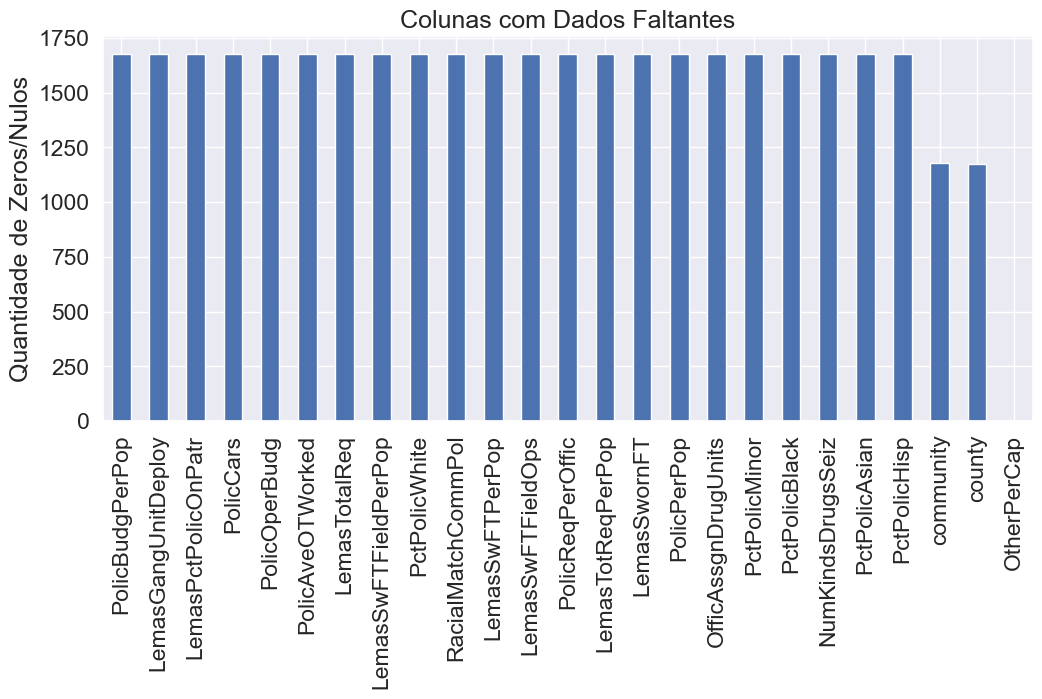

In [64]:
nulos_reais = nulos[nulos > 0].sort_values(ascending=False)
plt.figure(figsize=(12, 5))
nulos_reais.plot(kind='bar')
plt.title('Colunas com Dados Faltantes')
plt.ylabel('Quantidade de Zeros/Nulos')
plt.show()

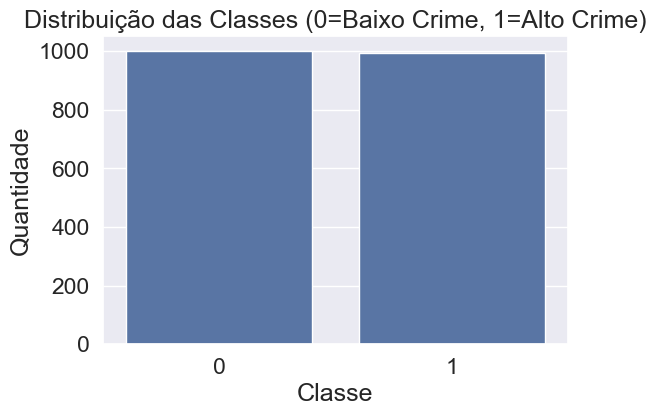

In [65]:
mediana = df['ViolentCrimesPerPop'].median()
classes_temporarias = (df['ViolentCrimesPerPop'] > mediana).astype(int)

plt.figure(figsize=(6, 4))
sns.countplot(x=classes_temporarias)
plt.title('Distribuição das Classes (0=Baixo Crime, 1=Alto Crime)')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.show()

In [66]:
porcentagem_nulos = (df.isnull().sum() / len(df)) * 100 #porcentagem dos nulos

acimaDeZero = porcentagem_nulos[porcentagem_nulos > 0].sort_values(ascending=False)

print("Análise de Colunas com Dados Faltantes (%):")
print(acimaDeZero.head(25))

#remove as de acima de 80%
colunas_remover = porcentagem_nulos[porcentagem_nulos > 80].index

print()
print(f"\nColunas eliminadas:")
print(list(colunas_remover))

df_novo = df.drop(columns=colunas_remover)
df_novo = df_novo.drop(columns=['communityname', 'state', 'fold'], errors='ignore')
df_novo = df_novo.fillna(df_novo.mean()) #preenche os NaN com a media

Análise de Colunas com Dados Faltantes (%):
LemasSwFTPerPop         84.002006
LemasTotalReq           84.002006
LemasSwornFT            84.002006
LemasSwFTFieldPerPop    84.002006
LemasSwFTFieldOps       84.002006
LemasTotReqPerPop       84.002006
RacialMatchCommPol      84.002006
PolicPerPop             84.002006
PolicReqPerOffic        84.002006
OfficAssgnDrugUnits     84.002006
NumKindsDrugsSeiz       84.002006
PolicAveOTWorked        84.002006
PctPolicWhite           84.002006
PctPolicBlack           84.002006
PctPolicHisp            84.002006
PctPolicAsian           84.002006
PctPolicMinor           84.002006
PolicOperBudg           84.002006
LemasPctPolicOnPatr     84.002006
LemasGangUnitDeploy     84.002006
PolicCars               84.002006
PolicBudgPerPop         84.002006
community               59.027081
county                  58.876630
OtherPerCap              0.050150
dtype: float64


Colunas eliminadas:
['LemasSwornFT', 'LemasSwFTPerPop', 'LemasSwFTFieldOps', 'LemasSwFTFi

C:\Users\caiov\AppData\Local\Temp\ipykernel_19744\3034902784.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_novo['Target'] = (df_novo['ViolentCrimesPerPop'] > mediana_crime).astype(int)


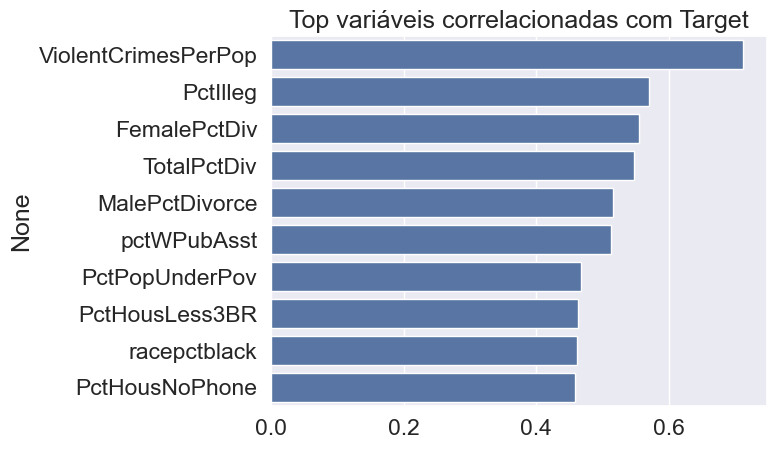

In [67]:
#transformando regressão em classificação (0 ou 1) usando a mediana
mediana_crime = df_novo['ViolentCrimesPerPop'].median()
df_novo['Target'] = (df_novo['ViolentCrimesPerPop'] > mediana_crime).astype(int)

corr = df_novo.corr()["Target"].sort_values(ascending=False)

top_corr = corr.drop("Target").head(10)

sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title("Top variáveis correlacionadas com Target")
plt.show()

C:\Users\caiov\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
C:\Users\caiov\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


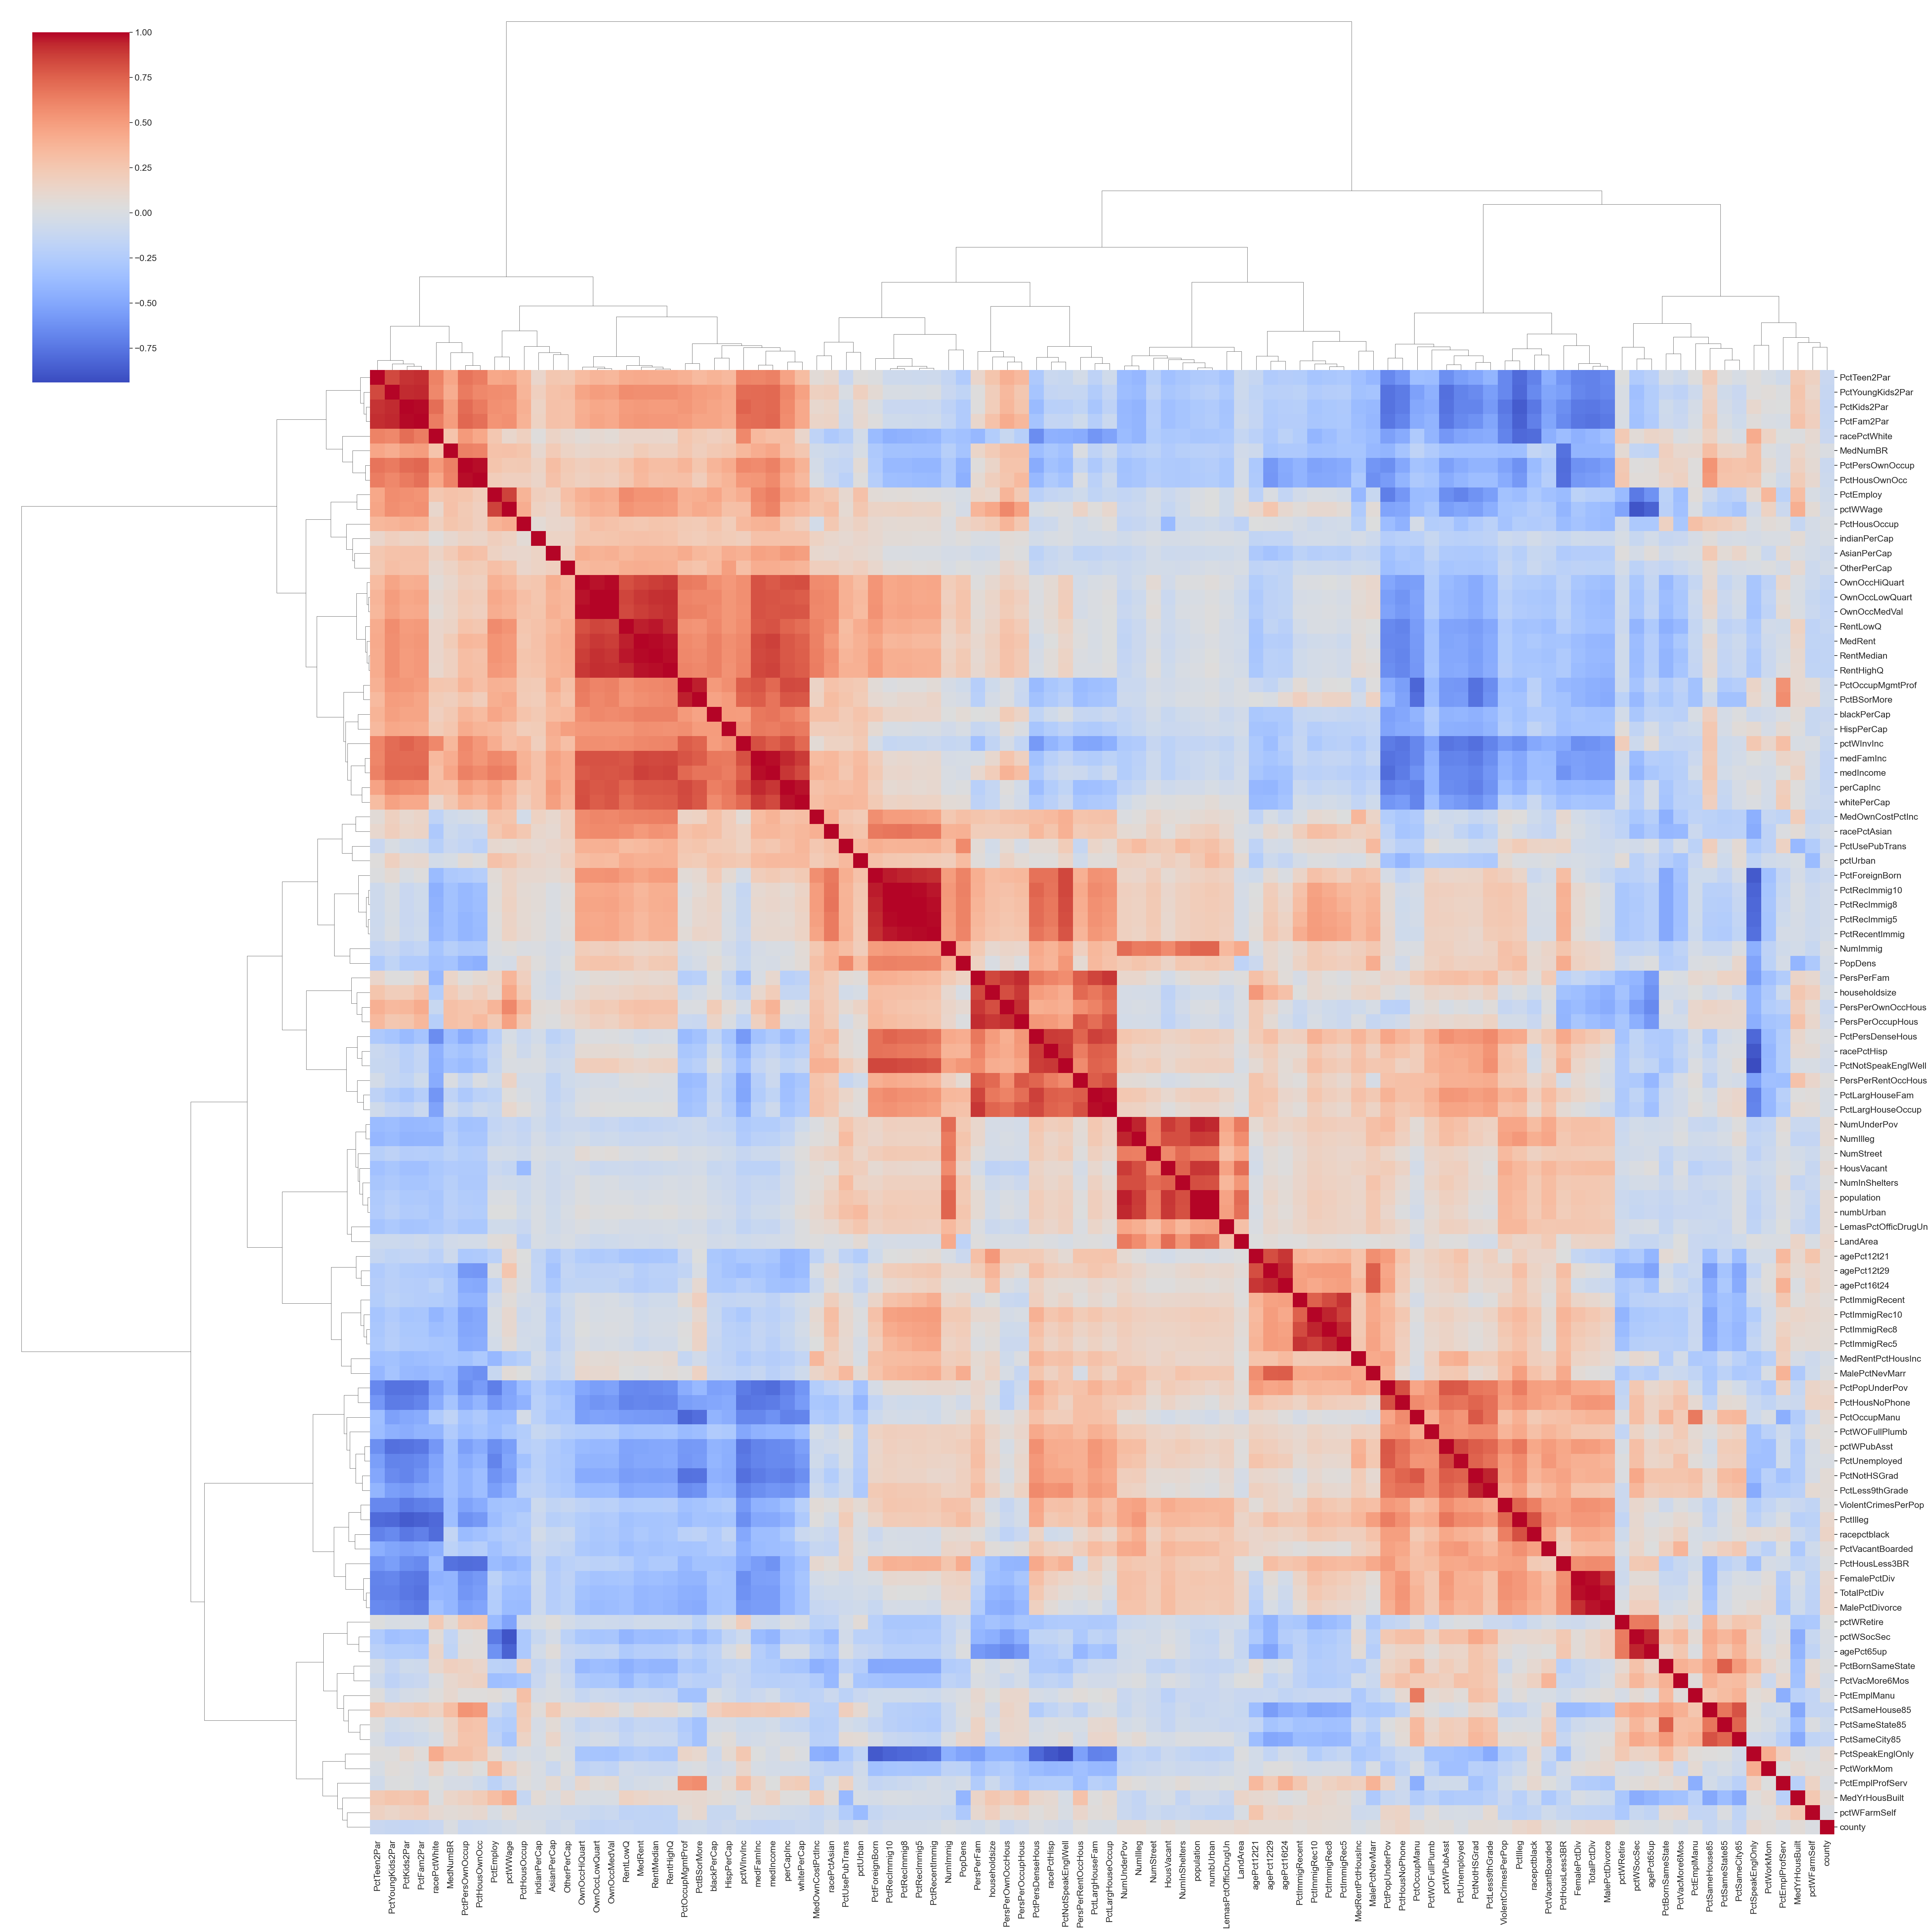

In [68]:
top_features = corr.drop("Target").abs().sort_values(ascending=False).head(100).index

corr_matrix = df_novo[top_features].corr()

sns.clustermap(
    corr_matrix,
    cmap="coolwarm",
    method="ward",
    figsize=(50,50)
)

plt.show()


#isso da problema na hora de gerar o heatmap

In [69]:
from scipy.cluster.hierarchy import linkage, fcluster

corr_matrix = df_novo.corr().abs()

# transforma correlação em distância
dist = 1 - corr_matrix

linkage_matrix = linkage(dist, method='ward')

clusters = fcluster(linkage_matrix, t=7, criterion='maxclust')

grupo_variaveis = {}

for col, cluster in zip(corr_matrix.columns, clusters):
    grupo_variaveis.setdefault(cluster, []).append(col)

for k, v in grupo_variaveis.items():
    print(f"Grupo {k}: {v}")

Grupo 7: ['county', 'community', 'racePctAsian', 'pctUrban', 'pctWWage', 'pctWFarmSelf', 'indianPerCap', 'AsianPerCap', 'OtherPerCap', 'PctEmploy', 'PctEmplManu', 'PctEmplProfServ', 'PctWorkMomYoungKids', 'PctWorkMom', 'PctHousOccup', 'PctVacMore6Mos', 'MedYrHousBuilt', 'MedOwnCostPctInc', 'MedOwnCostPctIncNoMtg', 'PctBornSameState', 'PctUsePubTrans']
Grupo 5: ['population', 'numbUrban', 'NumUnderPov', 'NumIlleg', 'HousVacant', 'NumInShelters', 'NumStreet', 'LandArea', 'LemasPctOfficDrugUn']
Grupo 4: ['householdsize', 'racePctHisp', 'PersPerFam', 'PctSpeakEnglOnly', 'PctNotSpeakEnglWell', 'PctLargHouseFam', 'PctLargHouseOccup', 'PersPerOccupHous', 'PersPerOwnOccHous', 'PersPerRentOccHous', 'PctPersDenseHous']
Grupo 1: ['racepctblack', 'racePctWhite', 'MalePctDivorce', 'FemalePctDiv', 'TotalPctDiv', 'PctFam2Par', 'PctKids2Par', 'PctYoungKids2Par', 'PctTeen2Par', 'PctIlleg', 'PctPersOwnOccup', 'PctHousLess3BR', 'MedNumBR', 'PctHousOwnOcc', 'PctVacantBoarded', 'PctWOFullPlumb', 'ViolentCr

C:\Users\caiov\AppData\Local\Temp\ipykernel_19744\1609992388.py:8: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(dist, method='ward')


In [70]:
grupos = {
    "Grupo 1 - Estrutura familiar e raça": ['racepctblack', 'racePctWhite', 'MalePctDivorce', 'FemalePctDiv', 'TotalPctDiv', 'PctFam2Par', 'PctKids2Par', 'PctYoungKids2Par', 'PctTeen2Par', 'PctIlleg', 'PctPersOwnOccup', 'PctHousLess3BR', 'MedNumBR', 'PctHousOwnOcc', 'PctVacantBoarded', 'PctWOFullPlumb', 'ViolentCrimesPerPop', 'Target'],

    "Grupo 2 - Renda e nível socioeconômico": ['medIncome', 'pctWInvInc', 'pctWPubAsst', 'medFamInc', 'perCapInc', 'whitePerCap', 'blackPerCap', 'HispPerCap', 'PctPopUnderPov', 'PctLess9thGrade', 'PctNotHSGrad', 'PctBSorMore', 'PctUnemployed', 'PctOccupManu', 'PctOccupMgmtProf', 'PctHousNoPhone', 'OwnOccLowQuart', 'OwnOccMedVal', 'OwnOccHiQuart', 'RentLowQ', 'RentMedian', 'RentHighQ', 'MedRent'],

    "Grupo 3 - Imigração": ['NumImmig', 'PctRecentImmig', 'PctRecImmig5', 'PctRecImmig8', 'PctRecImmig10', 'PctForeignBorn', 'PopDens'],

    "Grupo 4 - Estrutura familiar e densidade domiciliar": ['householdsize', 'racePctHisp', 'PersPerFam', 'PctSpeakEnglOnly', 'PctNotSpeakEnglWell', 'PctLargHouseFam', 'PctLargHouseOccup', 'PersPerOccupHous', 'PersPerOwnOccHous', 'PersPerRentOccHous', 'PctPersDenseHous'],

    "Grupo 5 - Tamanho populacional": ['population', 'numbUrban', 'NumUnderPov', 'NumIlleg', 'HousVacant', 'NumInShelters', 'NumStreet', 'LandArea', 'LemasPctOfficDrugUn'],

    "Grupo 6 - Estrutura etária": ['agePct12t21', 'agePct12t29', 'agePct16t24', 'agePct65up', 'pctWSocSec', 'pctWRetire', 'MalePctNevMarr', 'PctImmigRecent', 'PctImmigRec5', 'PctImmigRec8', 'PctImmigRec10', 'MedRentPctHousInc', 'PctSameHouse85', 'PctSameCity85', 'PctSameState85'],

    "Grupo 7 - Mercado de trabalho e urbanização": ['county', 'community', 'racePctAsian', 'pctUrban', 'pctWWage', 'pctWFarmSelf', 'indianPerCap', 'AsianPerCap', 'OtherPerCap', 'PctEmploy', 'PctEmplManu', 'PctEmplProfServ', 'PctWorkMomYoungKids', 'PctWorkMom', 'PctHousOccup', 'PctVacMore6Mos', 'MedYrHousBuilt', 'MedOwnCostPctInc', 'MedOwnCostPctIncNoMtg', 'PctBornSameState', 'PctUsePubTrans']

    
}

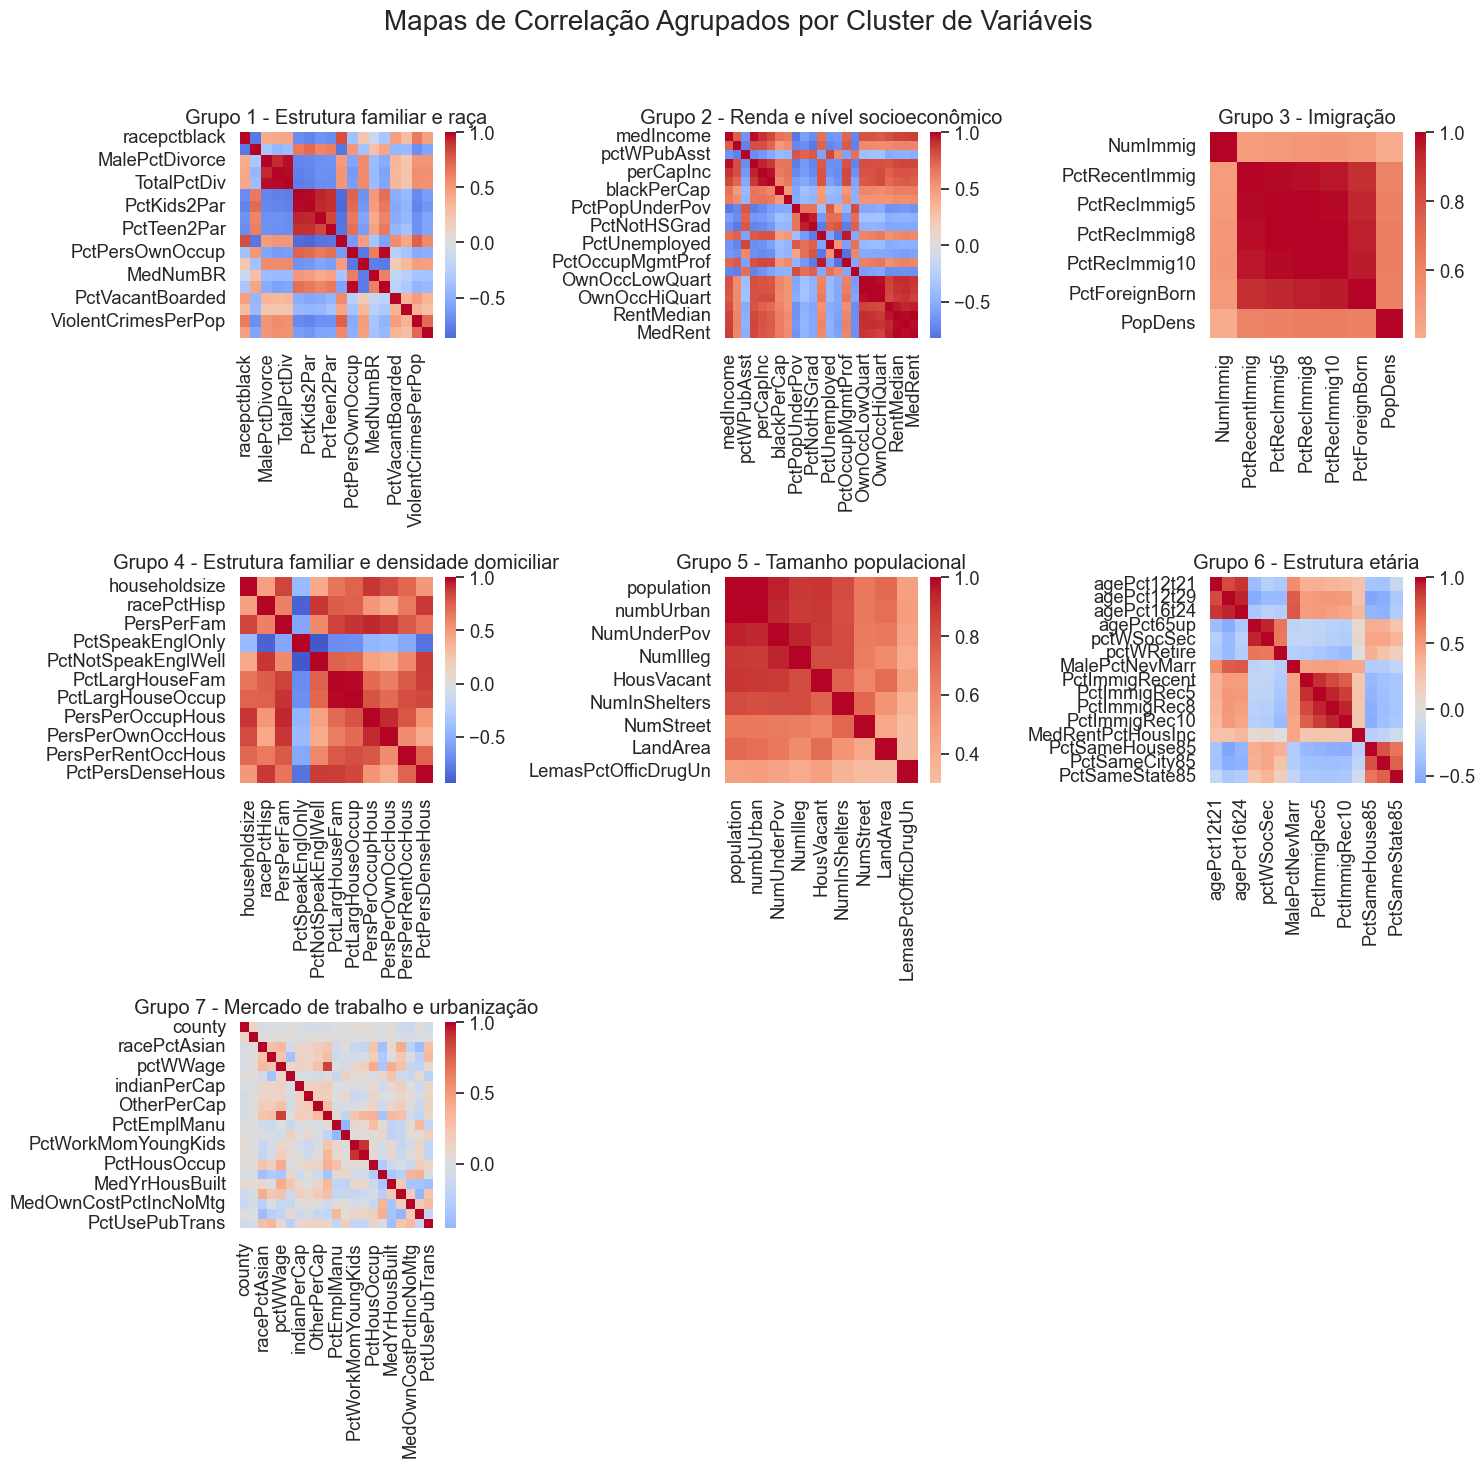

In [71]:
lista_grupos = list(grupos.items())
sns.set(font_scale=1.2)
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()


for i, (nome, cols) in enumerate(lista_grupos):

    sns.heatmap(
        df_novo[cols].corr(),
        cmap="coolwarm",
        center=0,
        ax=axes[i],
        cbar=True
    )

    axes[i].set_title(nome)

# remove eixos vazios
for j in range(len(lista_grupos), len(axes)):
    fig.delaxes(axes[j])

# título geral
plt.suptitle("Mapas de Correlação Agrupados por Cluster de Variáveis", fontsize=20)

# deixa espaço para o título
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig("matriz_clusters.png", dpi=150, bbox_inches='tight')

plt.show()

Treinos

In [72]:
X = df_novo.drop(columns=['Target', 'ViolentCrimesPerPop'])
y = df_novo['Target']

print(y)

#stratify mantem uma proporção de divisão no teste
#ex: tenho 100 bolas e vou treinar 30%, ele divide 15 em 15 para cada

X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.2,
    stratify=y,
    random_state=42)

print("Número de features:", X.shape[1])

0       1
1       1
2       1
3       0
4       0
       ..
1989    0
1990    1
1991    1
1992    1
1993    1
Name: Target, Length: 1994, dtype: int64
Número de features: 102


In [73]:
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Naive Bayes": GaussianNB()
}

resultado_semcv = []
resultados_cv = []

for nome, modelo in modelos.items():

    pipe_sem_pca = Pipeline([
        ("scaler", StandardScaler()),
        ("model", modelo)
    ])
    scores_sem_pca = cross_val_score(pipe_sem_pca, X_train, y_train, cv=5, scoring="accuracy")
    resultado_semcv.append([nome, scores_sem_pca.mean(), scores_sem_pca.std()])

    pipe_com_pca = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("model", modelo)
    ])

    scores_com_pca = cross_val_score(pipe_com_pca, X_train, y_train, cv=5, scoring="accuracy")
    resultados_cv.append([nome, scores_com_pca.mean(), scores_com_pca.std()])

df_semcv = pd.DataFrame(resultado_semcv, columns=["Modelo", "CV Accuracy", "Desvio"])
df_cv = pd.DataFrame(resultados_cv, columns=["Modelo", "CV Accuracy", "Desvio"])

print("--- Dataframe CV SEM PCA ---")
display(df_semcv)
print("\n--- Dataframe CV COM PCA ---")
display(df_cv)

--- Dataframe CV SEM PCA ---


,Modelo,CV Accuracy,Desvio
0,Logistic Regression,0.833229,0.017216
1,SVM,0.835737,0.013388
2,KNN,0.798119,0.015434
3,Decision Tree,0.747335,0.017124
4,Random Forest,0.831975,0.010031
5,Gradient Boosting,0.836991,0.015737
6,AdaBoost,0.808150,0.015151
7,Naive Bayes,0.803135,0.015786



--- Dataframe CV COM PCA ---


,Modelo,CV Accuracy,Desvio
0,Logistic Regression,0.835737,0.020082
1,SVM,0.833229,0.016870
2,KNN,0.803762,0.015306
3,Decision Tree,0.736677,0.013878
4,Random Forest,0.806897,0.016421
5,Gradient Boosting,0.815674,0.018322
6,AdaBoost,0.796238,0.012222
7,Naive Bayes,0.762382,0.018535


In [74]:
#accuracy: mede a proporção de acertos do modelo, De todas as previsões feitas, quantas estavam corretas?
#precision: quão confiáveis são as previsões positivas do modelo, Das vezes que o modelo disse que era positivo, quantas ele acertou?
#recall: quantos positivos reais o modelo conseguiu encontrar, Dos casos que realmente eram positivos, quantos o modelo conseguiu detectar?
#f1-score: média harmônica entre precision e recall, Qual é o equilíbrio entre precision e recall?

Analise Individual


AVALIAÇÃO NO CONJUNTO DE TESTE: SEM PCA

Resultados de cada target: Logistic Regression (Sem PCA)
              precision    recall  f1-score     support
0              0.826291  0.880000  0.852300  200.000000
1              0.870968  0.814070  0.841558  199.000000
accuracy       0.847118  0.847118  0.847118    0.847118
macro avg      0.848629  0.847035  0.846929  399.000000
weighted avg   0.848573  0.847118  0.846943  399.000000

Resultados de cada target: SVM (Sem PCA)
              precision    recall  f1-score     support
0              0.813953  0.875000  0.843373  200.000000
1              0.864130  0.798995  0.830287  199.000000
accuracy       0.837093  0.837093  0.837093    0.837093
macro avg      0.839042  0.836997  0.836830  399.000000
weighted avg   0.838979  0.837093  0.836847  399.000000

Resultados de cada target: KNN (Sem PCA)
              precision    recall  f1-score     support
0              0.826923  0.860000  0.843137  200.000000
1              0.853403  0.819095

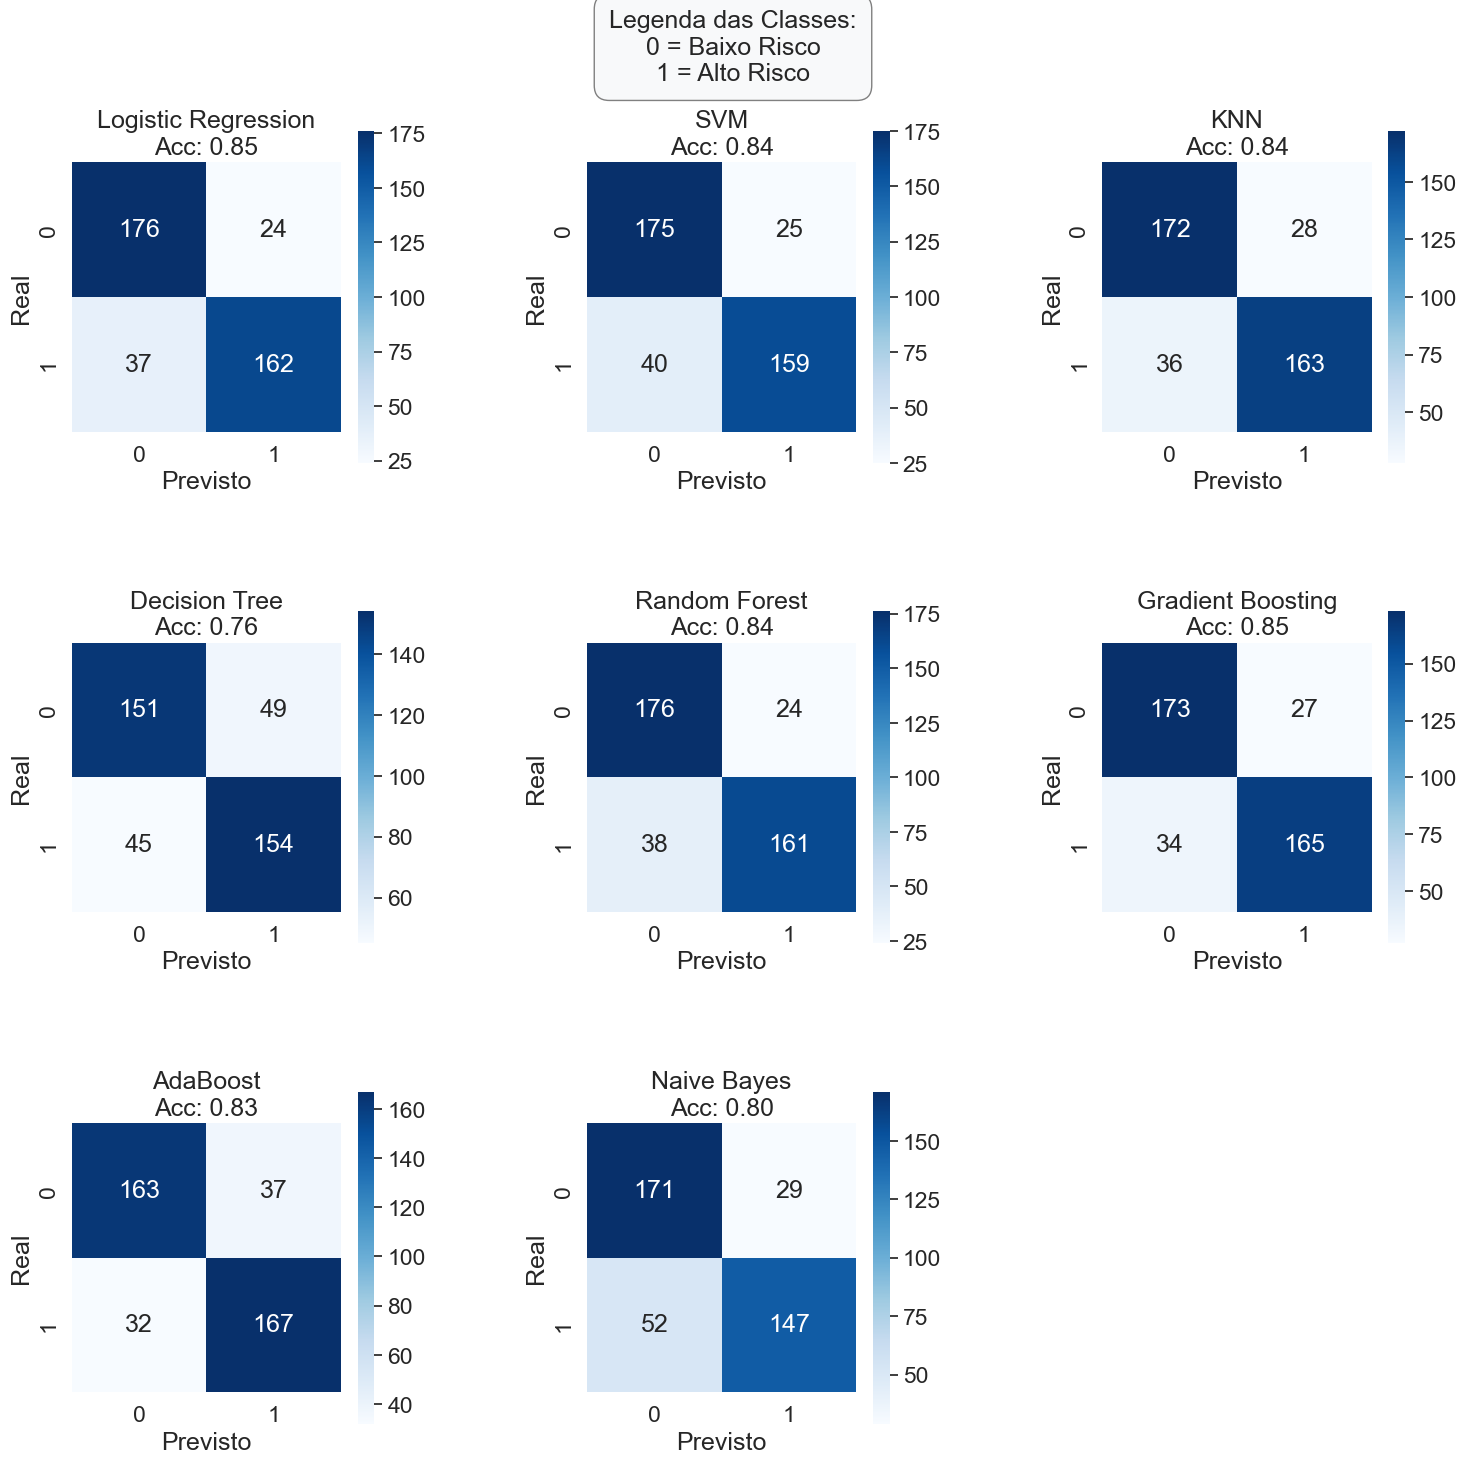


Resumo das Métricas (Sem PCA):


,Modelo,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.847118,0.870968,0.814070,0.841558
1,SVM,0.837093,0.864130,0.798995,0.830287
2,KNN,0.839599,0.853403,0.819095,0.835897
3,Decision Tree,0.764411,0.758621,0.773869,0.766169
4,Random Forest,0.844612,0.870270,0.809045,0.838542
5,Gradient Boosting,0.847118,0.859375,0.829146,0.843990
6,AdaBoost,0.827068,0.818627,0.839196,0.828784
7,Naive Bayes,0.796992,0.835227,0.738693,0.784000


In [ ]:
from sklearn.metrics import classification_report
import matplotlib.patches as mpatches


print("\n" + "="*50)
print("AVALIAÇÃO NO CONJUNTO DE TESTE: SEM PCA")
print("="*50)

resultados_sempca = []
sns.set(font_scale=1.5)

fig_sempca = plt.figure(figsize=(15, 15))

for i, (nome, modelo) in enumerate(modelos.items()):
    
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", modelo)
    ])
    
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    print(f"\nResultados de cada target: {nome} (Sem PCA)")
    print(pd.DataFrame(classification_report(y_test, pred, output_dict=True)).transpose())
    
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    resultados_sempca.append([nome, acc, prec, rec, f1]) 
    
    cm = confusion_matrix(y_test, pred)
    plt.subplot(3, 3, i+1) 
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, annot_kws={"size": 18}, square=True)
    plt.title(f"{nome}\nAcc: {acc:.2f}")
    plt.xlabel('Previsto')
    plt.ylabel('Real')

plt.tight_layout(h_pad=4.0, w_pad=4.0, rect=[0, 0, 1, 0.93])

texto_legenda = "Legenda das Classes:\n0 = Baixo Risco\n1 = Alto Risco"

fig_sempca.text(0.5, 0.98, texto_legenda, ha='center', va='top', fontsize=18,
                bbox=dict(boxstyle='round,pad=0.6', facecolor='#f8f9fa', edgecolor='gray'))

plt.savefig("matrizes_todas.jpg", dpi=150, bbox_inches='tight')
plt.show()

df_resultadossempca = pd.DataFrame(resultados_sempca, columns=["Modelo","Accuracy","Precision","Recall","F1"])
print("\nResumo das Métricas (Sem PCA):")
display(df_resultadossempca)


AVALIAÇÃO NO CONJUNTO DE TESTE: COM PCA

Resultados de cada target: Logistic Regression (Com PCA)
              precision    recall  f1-score     support
0              0.830097  0.855000  0.842365  200.000000
1              0.849741  0.824121  0.836735  199.000000
accuracy       0.839599  0.839599  0.839599    0.839599
macro avg      0.839919  0.839560  0.839550  399.000000
weighted avg   0.839894  0.839599  0.839557  399.000000

Resultados de cada target: SVM (Com PCA)
              precision    recall  f1-score     support
0              0.823810  0.865000  0.843902  200.000000
1              0.857143  0.814070  0.835052  199.000000
accuracy       0.839599  0.839599  0.839599    0.839599
macro avg      0.840476  0.839535  0.839477  399.000000
weighted avg   0.840434  0.839599  0.839488  399.000000

Resultados de cada target: KNN (Com PCA)
              precision    recall  f1-score     support
0              0.807512  0.860000  0.832930  200.000000
1              0.849462  0.793970

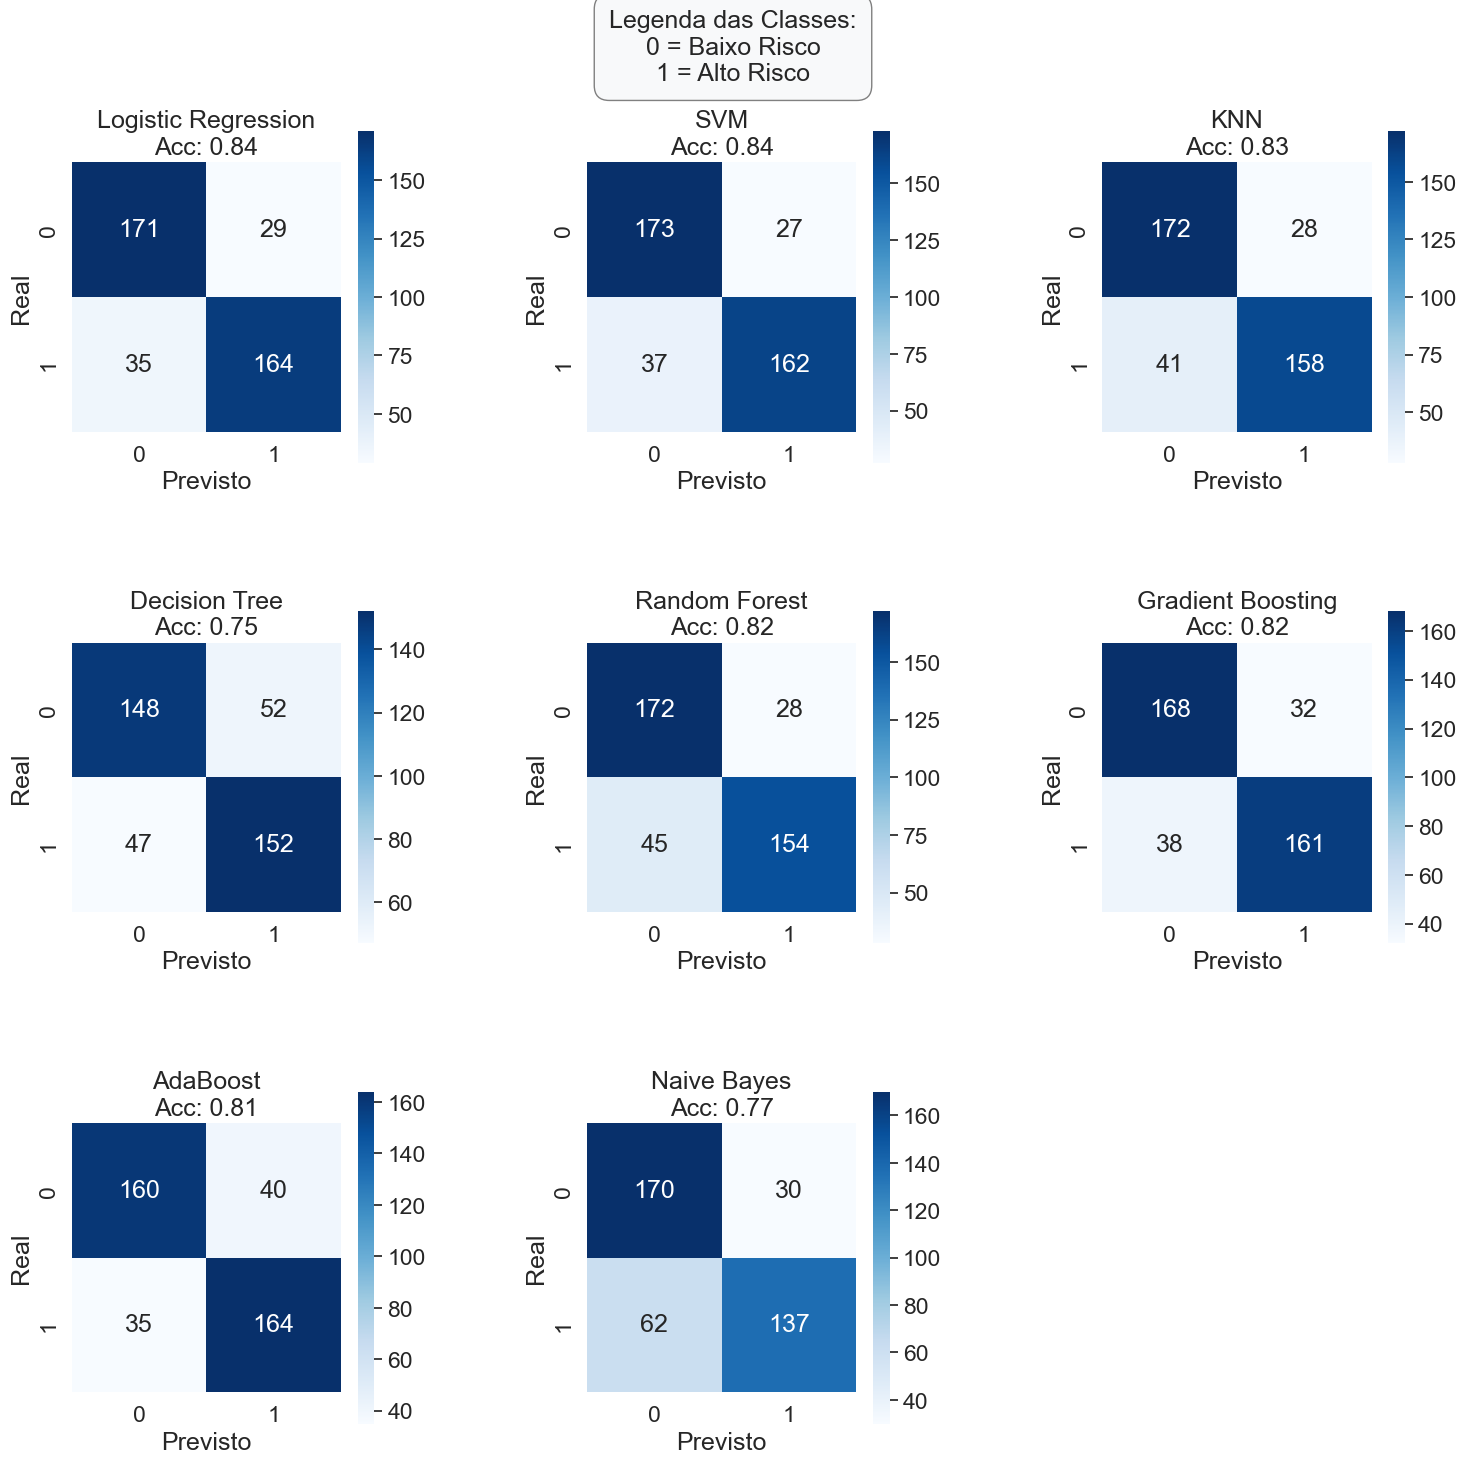


Resumo das Métricas (Com PCA):


,Modelo,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.839599,0.849741,0.824121,0.836735
1,SVM,0.839599,0.857143,0.814070,0.835052
2,KNN,0.827068,0.849462,0.793970,0.820779
3,Decision Tree,0.751880,0.745098,0.763819,0.754342
4,Random Forest,0.817043,0.846154,0.773869,0.808399
5,Gradient Boosting,0.824561,0.834197,0.809045,0.821429
6,AdaBoost,0.812030,0.803922,0.824121,0.813896
7,Naive Bayes,0.769424,0.820359,0.688442,0.748634


In [ ]:
print("\n" + "="*50)
print("AVALIAÇÃO NO CONJUNTO DE TESTE: COM PCA")
print("="*50)

resultados_compca = []
sns.set(font_scale=1.5)

fig_compca = plt.figure(figsize=(15, 15))

for i, (nome, modelo) in enumerate(modelos.items()):
    
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("model", modelo)
    ])
    
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    
    print(f"\nResultados de cada target: {nome} (Com PCA)")
    print(pd.DataFrame(classification_report(y_test, pred, output_dict=True)).transpose())
    
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    resultados_compca.append([nome, acc, prec, rec, f1])
    
    cm = confusion_matrix(y_test, pred)
    plt.subplot(3, 3, i+1) 
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, annot_kws={"size": 18}, square=True) 
    plt.title(f"{nome}\nAcc: {acc:.2f}")
    plt.xlabel('Previsto')
    plt.ylabel('Real')

plt.tight_layout(h_pad=4.0, w_pad=4.0, rect=[0, 0, 1, 0.93])

fig_compca.text(0.5, 0.98, texto_legenda, ha='center', va='top', fontsize=18,
                bbox=dict(boxstyle='round,pad=0.6', facecolor='#f8f9fa', edgecolor='gray'))

plt.show()

df_resultados = pd.DataFrame(resultados_compca, columns=["Modelo","Accuracy","Precision","Recall","F1"])
print("\nResumo das Métricas (Com PCA):")
display(df_resultados)